# 10. Harmonic Distributional Embeddings

This notebook builds distributional embeddings for harmonic `n`-gram classes.

Notebook 9 asks what changed. This notebook asks a different question:

**Which harmonic patterns play similar roles in songs, even when they are not structurally identical?**

The core idea is standard corpus linguistics / word embedding machinery:

1. choose a support-limited harmonic vocabulary from `H_n`;
2. count co-occurrences between harmonic classes;
3. convert co-occurrence counts to positive pointwise mutual information, `PPMI`;
4. factor the PPMI matrix with SVD;
5. use the resulting vectors as distributional embeddings.

The notebook keeps the literal `12 x n` pitch-class matrix embedding as a structural baseline, but the main event is now the PPMI/SVD embedding. The payoff is the comparison: structural neighbors answer “what looks alike?”, while distributional neighbors answer “what behaves alike in the corpus?”

## Setup

In [1]:
from collections import Counter
from itertools import combinations
from pathlib import Path
import importlib
import math
import os
import sys

CWD = Path.cwd()
ROOT = CWD.parent if (CWD / "utils").exists() else CWD
MPLCONFIGDIR = ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import duckdb
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = ROOT / "notebooks"
sys.path = [p for p in sys.path if p != str(NOTEBOOK_DIR)]
sys.path.insert(0, str(NOTEBOOK_DIR))
for module_name in list(sys.modules):
    if module_name == "utils" or module_name.startswith("utils."):
        del sys.modules[module_name]

from utils import duckdb_store as ds
from utils import ngram_features as nf

ds = importlib.reload(ds)
nf = importlib.reload(nf)
expected = {
    "duckdb_store": (NOTEBOOK_DIR / "utils" / "duckdb_store.py").resolve(),
    "ngram_features": (NOTEBOOK_DIR / "utils" / "ngram_features.py").resolve(),
}
loaded = {
    "duckdb_store": Path(ds.__file__).resolve(),
    "ngram_features": Path(nf.__file__).resolve(),
}
assert loaded == expected, f"Imported wrong utility module(s): {loaded}; expected {expected}"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

RAW_PATH = ROOT / "data" / "raw" / "chordonomicon_v2.csv"
DB_PATH = ROOT / "data" / "processed" / "harmonic_trends.duckdb"
OUT_DIR = ROOT / "data" / "processed" / "distributional_embeddings"
OUT_DIR.mkdir(parents=True, exist_ok=True)

NS = tuple(range(3, 9))
MIN_GLOBAL_COUNT = 2_500
TOP_HARMONIC_PER_N = 750
MIN_SONGS_PER_CONTEXT = 1
EMBEDDING_DIM = 32
STRUCTURAL_NEIGHBOR_SAMPLE = 300
NEIGHBORS_PER_ITEM = 10
CHUNKSIZE = 25_000

# Song-level co-occurrence is broad and stable. Local co-occurrence is more grammatical but heavier.
# Set MAX_SONGS to a small integer for smoke tests; leave None for the full corpus run.
RUN_SONG_CONTEXT = True
RUN_LOCAL_CONTEXT = True
LOCAL_CONTEXT_RADIUS = 8
MAX_SONGS = None
INCLUDE_SELF_COOCCURRENCE = False

assert RAW_PATH.exists(), RAW_PATH
assert DB_PATH.exists(), DB_PATH

{
    "python": sys.executable,
    "duckdb_version": duckdb.__version__,
    "out_dir": str(OUT_DIR),
    **{name: str(path) for name, path in loaded.items()},
}

{'python': '/usr/local/bin/python3',
 'duckdb_version': '1.5.2',
 'out_dir': '/Users/juansalinas/Documents/GitHub/harmonic-trends/data/processed/distributional_embeddings',
 'duckdb_store': '/Users/juansalinas/Documents/GitHub/harmonic-trends/notebooks/utils/duckdb_store.py',
 'ngram_features': '/Users/juansalinas/Documents/GitHub/harmonic-trends/notebooks/utils/ngram_features.py'}

## Helpers

In [2]:
def harmonic_key_to_vector(harmonic_key: str) -> np.ndarray:
    return nf.matrix_from_key(harmonic_key).reshape(-1).astype(float)


def l2_normalize(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms


def cosine_neighbors(embeddings: np.ndarray, ids: list[str], labels: list[str], k: int) -> pd.DataFrame:
    X = l2_normalize(embeddings)
    similarity = X @ X.T
    rows = []
    for i, source_id in enumerate(ids):
        order = np.argsort(-similarity[i])
        rank = 0
        for j in order:
            if i == j:
                continue
            rank += 1
            rows.append(
                {
                    "source_id": source_id,
                    "source_label": labels[i],
                    "target_id": ids[j],
                    "target_label": labels[j],
                    "neighbor_rank": rank,
                    "cosine_similarity": float(similarity[i, j]),
                    "cosine_distance": float(1 - similarity[i, j]),
                }
            )
            if rank >= k:
                break
    return pd.DataFrame(rows)


def pca_numpy(X: np.ndarray, n_components: int) -> tuple[np.ndarray, pd.DataFrame]:
    X = np.asarray(X, dtype=float)
    mean = X.mean(axis=0, keepdims=True)
    centered = X - mean
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    n_components = min(n_components, U.shape[1])
    scores = U[:, :n_components] * S[:n_components]
    denom = np.sum(S ** 2)
    explained = (S[:n_components] ** 2) / denom if denom > 0 else np.zeros(n_components)
    summary = pd.DataFrame(
        {
            "component": [f"PC{i + 1}" for i in range(n_components)],
            "explained_variance_ratio": explained,
            "cumulative_explained_variance_ratio": np.cumsum(explained),
        }
    )
    return scores, summary


def svd_ppmi_embedding(ppmi: np.ndarray, dim: int, alpha: float = 0.5) -> tuple[np.ndarray, pd.DataFrame]:
    U, S, Vt = np.linalg.svd(ppmi, full_matrices=False)
    dim = min(dim, len(S))
    embeddings = U[:, :dim] * (S[:dim] ** alpha)
    denom = np.sum(S ** 2)
    summary = pd.DataFrame(
        {
            "component": [f"SVD{i + 1}" for i in range(dim)],
            "singular_value": S[:dim],
            "energy_ratio": (S[:dim] ** 2) / denom if denom > 0 else np.zeros(dim),
            "cumulative_energy_ratio": np.cumsum((S[:dim] ** 2) / denom) if denom > 0 else np.zeros(dim),
        }
    )
    return embeddings, summary


def cooccurrence_to_ppmi(cooc: np.ndarray, *, shift: float = 1.0, include_self: bool = INCLUDE_SELF_COOCCURRENCE) -> np.ndarray:
    cooc = np.asarray(cooc, dtype=float).copy()
    if not include_self:
        np.fill_diagonal(cooc, 0.0)
    total = cooc.sum()
    if total <= 0:
        return np.zeros_like(cooc)
    row = cooc.sum(axis=1, keepdims=True)
    col = cooc.sum(axis=0, keepdims=True)
    expected = row @ col / total
    with np.errstate(divide="ignore", invalid="ignore"):
        pmi = np.log(cooc / expected) - math.log(shift)
    pmi[~np.isfinite(pmi)] = 0.0
    return np.maximum(pmi, 0.0)


def save_matrix_npz(path: Path, matrix: np.ndarray, ids: list[str]) -> None:
    np.savez_compressed(path, matrix=matrix, ids=np.asarray(ids, dtype=object))

## Build A Support-Limited Harmonic Vocabulary

The full `H_n` vocabulary is too large for dense PPMI matrices. This first pass keeps frequent, interpretable harmonic classes per `n`. Increase `TOP_HARMONIC_PER_N` or lower `MIN_GLOBAL_COUNT` later if the embedding is too narrow.

In [3]:
con = duckdb.connect(str(DB_PATH), read_only=True)
ds.configure_connection(con)
try:
    vocab = con.execute(
        """
        SELECT *
        FROM (
            SELECT
                n,
                harmonic_id,
                harmonic_key,
                example_ngram,
                count AS global_count,
                frequency AS global_frequency,
                n_exact_ngrams,
                ROW_NUMBER() OVER (PARTITION BY n ORDER BY count DESC, harmonic_id) AS rank_within_n
            FROM harmonic_ngrams
            WHERE n BETWEEN 3 AND 8
              AND count >= ?
        )
        WHERE rank_within_n <= ?
        ORDER BY n, rank_within_n
        """,
        [MIN_GLOBAL_COUNT, TOP_HARMONIC_PER_N],
    ).fetchdf()
finally:
    con.close()

vocab["label"] = vocab["example_ngram"] + " (" + vocab["harmonic_id"].str.split("_", n=1).str[-1].str[:6] + ")"
vocab.to_csv(OUT_DIR / "harmonic_distributional_vocabulary.csv", index=False)

display(vocab.head())
display(vocab.groupby("n").agg(classes=("harmonic_id", "size"), min_count=("global_count", "min"), max_count=("global_count", "max")))

,n,harmonic_id,harmonic_key,example_ngram,global_count,global_frequency,n_exact_ngrams,rank_within_n,label
0,3,H3_ede3c4f53675bbb0,3:111000000000101010000101000010000000,G C G,2203877,0.043525,464,1,G C G (ede3c4)
1,3,H3_35d6bfda85b78e3b,3:101000010000101000000111000000000010,C G C,1907266,0.037667,430,2,C G C (35d6bf)
2,3,H3_4e99eecf61b0edec,3:100000011000100000001110000001000010,C G D,1827464,0.036091,396,3,C G D (4e99ee)
3,3,H3_5f9ccd30c6b35272,3:100000011000100000010101000010000001,C D G,1273259,0.025146,357,4,C D G (5f9ccd)
4,3,H3_614d8a0823c338e1,3:110000001000100011000100000010001000,D G C,1183031,0.023364,353,5,D G C (614d8a)


,classes,min_count,max_count
n,,,
3,750,4380,2203877
4,750,7440,1007932
5,750,6826,667134
6,750,5939,467821
7,750,4795,357565
8,750,3843,292190


## Stream Songs Into Co-Occurrence Counts

Two contexts are supported:

- **song context**: two harmonic classes co-occur if both appear in the same song;
- **local context**: two harmonic classes co-occur if they appear within `LOCAL_CONTEXT_RADIUS` positions in the same song's `H_n` sequence.

Song context captures broad distributional role. Local context is closer to harmonic grammar. By default, self-cooccurrence is removed before PPMI so the graph emphasizes relationships between different harmonic classes rather than self-loops.

In [4]:
def empty_context_state(vocab: pd.DataFrame):
    by_n = {}
    for n, sub in vocab.groupby("n"):
        ids = sub["harmonic_id"].tolist()
        by_n[int(n)] = {
            "ids": ids,
            "id_to_index": {hid: i for i, hid in enumerate(ids)},
            "cooc": np.zeros((len(ids), len(ids)), dtype=np.float64),
            "occurrence": np.zeros(len(ids), dtype=np.float64),
            "songs_with_term": np.zeros(len(ids), dtype=np.float64),
            "n_songs": 0,
            "n_windows": 0,
        }
    return by_n


def song_harmonic_sequence(tokens: list[str], n: int, id_to_index: dict[str, int]) -> list[int]:
    seq = []
    for ngram in nf.chord_ngrams(tokens, n):
        try:
            hid = nf.harmonic_id(nf.first_root_normalized_key(ngram))
        except Exception:
            continue
        idx = id_to_index.get(hid)
        if idx is not None:
            seq.append(idx)
    return seq


def update_song_context(state, n: int, seq: list[int]) -> None:
    if len(seq) < MIN_SONGS_PER_CONTEXT:
        return
    unique = sorted(set(seq))
    if not unique:
        return
    state[n]["n_songs"] += 1
    state[n]["n_windows"] += len(seq)
    for idx, c in Counter(seq).items():
        state[n]["occurrence"][idx] += c
    for idx in unique:
        state[n]["songs_with_term"][idx] += 1
        state[n]["cooc"][idx, idx] += 1
    for i, j in combinations(unique, 2):
        state[n]["cooc"][i, j] += 1
        state[n]["cooc"][j, i] += 1


def update_local_context(state, n: int, seq: list[int], radius: int) -> None:
    if not seq:
        return
    state[n]["n_songs"] += 1
    state[n]["n_windows"] += len(seq)
    for idx, c in Counter(seq).items():
        state[n]["occurrence"][idx] += c
        state[n]["songs_with_term"][idx] += 1
    cooc = state[n]["cooc"]
    for pos, i in enumerate(seq):
        start = max(0, pos - radius)
        end = min(len(seq), pos + radius + 1)
        for q in range(start, end):
            if q == pos:
                continue
            j = seq[q]
            cooc[i, j] += 1


def build_cooccurrence_states(vocab: pd.DataFrame):
    song_state = empty_context_state(vocab) if RUN_SONG_CONTEXT else None
    local_state = empty_context_state(vocab) if RUN_LOCAL_CONTEXT else None
    processed = 0

    for chunk in pd.read_csv(RAW_PATH, usecols=["id", "chords"], chunksize=CHUNKSIZE):
        for row in chunk.itertuples(index=False):
            if MAX_SONGS is not None and processed >= MAX_SONGS:
                return song_state, local_state, processed
            tokens = nf.chord_tokens(row.chords)
            for n in NS:
                ref_state = song_state if song_state is not None else local_state
                id_to_index = ref_state[n]["id_to_index"]
                seq = song_harmonic_sequence(tokens, n, id_to_index)
                if song_state is not None:
                    update_song_context(song_state, n, seq)
                if local_state is not None:
                    update_local_context(local_state, n, seq, LOCAL_CONTEXT_RADIUS)
            processed += 1
    return song_state, local_state, processed

song_state, local_state, processed_songs = build_cooccurrence_states(vocab)
processed_songs

679807

## Convert Co-Occurrence Counts To PPMI

In [5]:
def state_to_tables(state: dict[int, dict], context_name: str) -> tuple[pd.DataFrame, dict[int, np.ndarray], dict[int, np.ndarray]]:
    summaries = []
    cooc_mats = {}
    ppmi_mats = {}
    for n, item in state.items():
        cooc = item["cooc"]
        ppmi = cooccurrence_to_ppmi(cooc)
        cooc_mats[n] = cooc
        ppmi_mats[n] = ppmi
        summaries.append(
            {
                "context": context_name,
                "n": n,
                "classes": len(item["ids"]),
                "songs_observed": int(item["n_songs"]),
                "windows_observed": int(item["n_windows"]),
                "nonzero_cooccurrences": int(np.count_nonzero(cooc)),
                "cooccurrence_mass": float(cooc.sum()),
                "nonzero_ppmi": int(np.count_nonzero(ppmi)),
                "mean_positive_ppmi": float(ppmi[ppmi > 0].mean()) if np.any(ppmi > 0) else 0.0,
            }
        )
        save_matrix_npz(OUT_DIR / f"{context_name}_H{n}_cooccurrence.npz", cooc, item["ids"])
        save_matrix_npz(OUT_DIR / f"{context_name}_H{n}_ppmi.npz", ppmi, item["ids"])
    return pd.DataFrame(summaries), cooc_mats, ppmi_mats

summary_tables = []
cooc_by_context = {}
ppmi_by_context = {}
if song_state is not None:
    summary, cooc_mats, ppmi_mats = state_to_tables(song_state, "song_context")
    summary_tables.append(summary)
    cooc_by_context["song_context"] = cooc_mats
    ppmi_by_context["song_context"] = ppmi_mats
if local_state is not None:
    summary, cooc_mats, ppmi_mats = state_to_tables(local_state, "local_context")
    summary_tables.append(summary)
    cooc_by_context["local_context"] = cooc_mats
    ppmi_by_context["local_context"] = ppmi_mats

cooccurrence_summary = pd.concat(summary_tables, ignore_index=True)
display(cooccurrence_summary)
cooccurrence_summary.to_csv(OUT_DIR / "harmonic_cooccurrence_summary.csv", index=False)

,context,n,classes,songs_observed,windows_observed,nonzero_cooccurrences,cooccurrence_mass,nonzero_ppmi,mean_positive_ppmi
0,song_context,3,750,672110,43595381,552944,175903562.0,188856,0.815025
1,song_context,4,750,636650,33323695,558654,165924945.0,157912,0.693008
2,song_context,5,750,593190,24732181,552700,115293869.0,149008,0.690915
3,song_context,6,750,547371,19106386,542804,78624255.0,139280,0.720398
4,song_context,7,750,500539,15225493,526142,52190542.0,128916,0.779548
5,song_context,8,750,456565,12538355,497678,36425257.0,118566,0.834221
6,local_context,3,750,672110,43595381,523436,649479150.0,143786,1.094400
7,local_context,4,750,636650,33323695,547366,488553576.0,100224,0.991281
8,local_context,5,750,593190,24732181,536002,355052816.0,77650,0.965889
9,local_context,6,750,547371,19106386,516464,269052152.0,64068,1.019400


## Factor PPMI With SVD

For each `n` and context type, compute embeddings from the PPMI matrix:

$$
PPMI \approx U_k S_k V_k^T, \quad z_g = U_k S_k^{1/2}.
$$

The `S^{1/2}` scaling is a common symmetric choice for PPMI embeddings.

In [6]:
embedding_tables = []
svd_summaries = []
embedding_arrays = {}

for context_name, ppmi_mats in ppmi_by_context.items():
    embedding_arrays[context_name] = {}
    for n, ppmi in ppmi_mats.items():
        ids = (song_state if context_name == "song_context" else local_state)[n]["ids"]
        sub_vocab = vocab[vocab["n"] == n].set_index("harmonic_id").loc[ids].reset_index()
        embeddings, summary = svd_ppmi_embedding(ppmi, EMBEDDING_DIM, alpha=0.5)
        embedding_arrays[context_name][n] = embeddings
        for i, row in summary.iterrows():
            svd_summaries.append({"context": context_name, "n": n, **row.to_dict()})
        for row, vec in zip(sub_vocab.itertuples(index=False), embeddings):
            embedding_tables.append(
                {
                    "context": context_name,
                    "n": n,
                    "harmonic_id": row.harmonic_id,
                    "example_ngram": row.example_ngram,
                    "global_count": row.global_count,
                    "global_frequency": row.global_frequency,
                    **{f"z{i + 1}": float(vec[i]) for i in range(embeddings.shape[1])},
                }
            )

ppmi_embeddings = pd.DataFrame(embedding_tables)
ppmi_svd_summary = pd.DataFrame(svd_summaries)

display(ppmi_svd_summary.groupby(["context", "n"]).head(5))
display(ppmi_embeddings.head())

ppmi_embeddings.to_csv(OUT_DIR / "harmonic_ppmi_svd_embeddings.csv", index=False)
ppmi_svd_summary.to_csv(OUT_DIR / "harmonic_ppmi_svd_summary.csv", index=False)

,context,n,component,singular_value,energy_ratio,cumulative_energy_ratio
0,song_context,3,SVD1,302.839488,0.356582,0.356582
1,song_context,3,SVD2,177.426996,0.122398,0.478980
2,song_context,3,SVD3,165.822400,0.106911,0.585891
3,song_context,3,SVD4,133.184316,0.068967,0.654857
4,song_context,3,SVD5,118.495534,0.054593,0.709451
32,song_context,4,SVD1,181.273986,0.199769,0.199769
33,song_context,4,SVD2,149.096627,0.135143,0.334912
34,song_context,4,SVD3,140.181537,0.119464,0.454376
35,song_context,4,SVD4,115.746778,0.081447,0.535823
36,song_context,4,SVD5,99.459868,0.060139,0.595962


,context,n,harmonic_id,example_ngram,global_count,global_frequency,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15,z16,z17,z18,z19,z20,z21,z22,z23,z24,z25,z26,z27,z28,z29,z30,z31,z32
0,song_context,3,H3_ede3c4f53675bbb0,G C G,2203877,0.043525,-0.043691,-0.018048,-0.003019,-0.075877,-0.009403,0.035050,-0.097557,0.021512,-0.004743,0.078863,-0.053397,0.044841,-0.012317,0.014660,-0.030214,0.031148,-0.073579,0.040142,0.075690,-0.003072,0.001144,-0.075013,0.013066,-0.060488,0.035041,-0.041004,0.070512,-0.055334,0.003014,-0.006188,-0.038071,0.025411
1,song_context,3,H3_35d6bfda85b78e3b,C G C,1907266,0.037667,-0.039727,-0.013725,-0.003029,-0.066708,0.002447,0.031089,-0.097080,0.020967,-0.009362,0.068209,-0.043056,0.031394,-0.009716,0.013007,-0.035714,0.045186,-0.068452,0.036591,0.083137,0.009479,0.000803,-0.077830,0.021417,-0.050496,0.018946,-0.056228,0.079314,-0.074718,-0.025149,-0.014396,-0.029185,0.008552
2,song_context,3,H3_4e99eecf61b0edec,C G D,1827464,0.036091,-0.021449,0.014675,-0.000036,-0.029054,0.019492,-0.002520,-0.036270,0.032825,-0.035319,0.043191,0.002118,0.009529,0.002591,0.033884,-0.028234,-0.002710,-0.021981,0.033854,0.004891,0.001740,-0.005017,-0.044817,0.020806,-0.035637,0.002837,-0.089960,-0.029104,-0.073355,-0.025696,-0.052668,-0.009664,-0.031518
3,song_context,3,H3_5f9ccd30c6b35272,C D G,1273259,0.025146,-0.022388,-0.000831,-0.000176,-0.016502,0.016763,-0.002484,-0.035982,0.029995,-0.020630,0.016942,0.009600,-0.034362,-0.001857,0.023218,0.036415,0.035956,-0.050350,0.037040,0.056088,0.033982,-0.063681,0.040891,0.073039,-0.006090,0.036033,-0.053560,0.021546,-0.022581,0.022036,-0.058158,0.033155,0.006889
4,song_context,3,H3_614d8a0823c338e1,D G C,1183031,0.023364,-0.025020,-0.012653,-0.002240,-0.039231,0.018276,-0.004341,-0.061998,0.025127,-0.013778,0.031452,-0.009056,0.003493,0.007268,0.004117,0.016358,0.013639,-0.031432,0.034516,0.142695,0.013654,-0.040218,-0.005260,0.042829,-0.025215,0.015296,-0.025373,0.044668,-0.058406,0.001557,-0.066483,0.000761,0.046676


## Distributional Nearest Neighbors

These neighbors are the interpretive payoff. They answer: which harmonic classes occur in similar contexts? Compare song-level and local-context results.

In [7]:
neighbor_tables = []
for context_name, by_n in embedding_arrays.items():
    for n, X in by_n.items():
        ids = (song_state if context_name == "song_context" else local_state)[n]["ids"]
        labels = vocab[vocab["n"] == n].set_index("harmonic_id").loc[ids]["label"].tolist()
        neighbors = cosine_neighbors(X, ids, labels, NEIGHBORS_PER_ITEM)
        neighbors.insert(0, "context", context_name)
        neighbors.insert(1, "n", n)
        neighbor_tables.append(neighbors)

distributional_neighbors = pd.concat(neighbor_tables, ignore_index=True)
display(distributional_neighbors.groupby(["context", "n"], as_index=False).head(12))
distributional_neighbors.to_csv(OUT_DIR / "harmonic_distributional_neighbors.csv", index=False)

,context,n,source_id,source_label,target_id,target_label,neighbor_rank,cosine_similarity,cosine_distance
0,song_context,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_35d6bfda85b78e3b,C G C (35d6bf),1,0.973929,0.026071
1,song_context,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_614d8a0823c338e1,D G C (614d8a),2,0.696785,0.303215
2,song_context,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_6e80fd020e3d91f5,C G G7 (6e80fd),3,0.678590,0.321410
3,song_context,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_b2630ff422c61559,G C G7 (b2630f),4,0.675391,0.324609
4,song_context,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_de5160951db380d6,C C7 G (de5160),5,0.643941,0.356059
...,...,...,...,...,...,...,...,...,...
82507,local_context,8,H8_55aa31cb16dc163b,C G Amin F C G Amin F (55aa31),H8_6471f51d219fb7ce,C G Amin C G Amin F C (6471f5),8,0.928382,0.071618
82508,local_context,8,H8_55aa31cb16dc163b,C G Amin F C G Amin F (55aa31),H8_7d80718b4b2d0788,G Amin C G Amin F C G (7d8071),9,0.927877,0.072123
82509,local_context,8,H8_55aa31cb16dc163b,C G Amin F C G Amin F (55aa31),H8_3b58eac05b7da350,C G Amin F C G Amin C (3b58ea),10,0.924771,0.075229
82510,local_context,8,H8_559240cc08bfac6e,Amin F C G Amin F C G (559240),H8_3df2bb6a1623475c,G Amin F C G Amin F C (3df2bb),1,0.996674,0.003326


### Neighbor Reading

Nearest neighbors here should not be read as substitutions in a chord chart. They are corpus-role neighbors: patterns that tend to appear with similar surrounding harmonic vocabularies. The most interesting cases are often those that are not structurally close but are distributionally close.

## Structural Baseline Neighbors

The structural embedding flattens each `12 x n` pitch-class matrix. Comparing it to PPMI neighbors shows where structural similarity and corpus-role similarity agree or diverge.

In [8]:
structural_neighbor_tables = []
for n, sub in vocab.groupby("n"):
    sub = sub.head(STRUCTURAL_NEIGHBOR_SAMPLE).copy()
    X = np.vstack([harmonic_key_to_vector(key) for key in sub["harmonic_key"]])
    neighbors = cosine_neighbors(X, sub["harmonic_id"].tolist(), sub["label"].tolist(), NEIGHBORS_PER_ITEM)
    neighbors.insert(0, "n", n)
    structural_neighbor_tables.append(neighbors)

structural_neighbors = pd.concat(structural_neighbor_tables, ignore_index=True)
display(structural_neighbors.groupby("n", as_index=False).head(12))
structural_neighbors.to_csv(OUT_DIR / "harmonic_structural_baseline_neighbors.csv", index=False)

,n,source_id,source_label,target_id,target_label,neighbor_rank,cosine_similarity,cosine_distance
0,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_01773335cfdd22ef,G7 C G (017733),1,0.948683,0.051317
1,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_532b8cd668c5c5d9,G Cadd9 G (532b8c),2,0.948683,0.051317
2,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_25f827b91813752e,G Amin7 G (25f827),3,0.948683,0.051317
3,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_f5c959235e704369,G C Emin7 (f5c959),4,0.948683,0.051317
4,3,H3_ede3c4f53675bbb0,G C G (ede3c4),H3_216504085aadb6d8,C Fmaj7 C (216504),5,0.948683,0.051317
...,...,...,...,...,...,...,...,...
15007,8,H8_55aa31cb16dc163b,C G Amin F C G Amin F (55aa31),H8_7f64acc42494a7f9,C G F Amin C G F Amin (7f64ac),8,0.833333,0.166667
15008,8,H8_55aa31cb16dc163b,C G Amin F C G Amin F (55aa31),H8_a92cd0c79ac1d46e,G Amin Emin C G Amin Emin C (a92cd0),9,0.833333,0.166667
15009,8,H8_55aa31cb16dc163b,C G Amin F C G Amin F (55aa31),H8_24124e5b261e986c,C G Amin F C G C G (24124e),10,0.833333,0.166667
15010,8,H8_559240cc08bfac6e,Amin F C G Amin F C G (559240),H8_28d9ea79b0e558aa,Amin F C Emin Amin F C Emin (28d9ea),1,0.916667,0.083333


## Where Distributional And Structural Embeddings Disagree

This table compares the top structural neighbors against the top distributional neighbors for the same source class. Low overlap is where musical interpretation gets interesting.

In [9]:
comparison_rows = []
for context_name in sorted(distributional_neighbors["context"].unique()):
    dist_sub = distributional_neighbors[distributional_neighbors["context"] == context_name]
    for n in NS:
        dist_n = dist_sub[dist_sub["n"] == n]
        struct_n = structural_neighbors[structural_neighbors["n"] == n]
        common_sources = sorted(set(dist_n["source_id"]) & set(struct_n["source_id"]))
        for source_id in common_sources:
            d_targets = set(dist_n[(dist_n["source_id"] == source_id) & (dist_n["neighbor_rank"] <= 5)]["target_id"])
            s_targets = set(struct_n[(struct_n["source_id"] == source_id) & (struct_n["neighbor_rank"] <= 5)]["target_id"])
            comparison_rows.append(
                {
                    "context": context_name,
                    "n": n,
                    "source_id": source_id,
                    "source_label": dist_n[dist_n["source_id"] == source_id]["source_label"].iloc[0],
                    "top5_overlap": len(d_targets & s_targets),
                    "distributional_only": "; ".join(sorted(d_targets - s_targets)),
                    "structural_only": "; ".join(sorted(s_targets - d_targets)),
                }
            )

neighbor_comparison = pd.DataFrame(comparison_rows)
display(neighbor_comparison.sort_values(["top5_overlap", "context", "n"]).head(30))
neighbor_comparison.to_csv(OUT_DIR / "structural_vs_distributional_neighbor_overlap.csv", index=False)

,context,n,source_id,source_label,top5_overlap,distributional_only,structural_only
0,local_context,3,H3_00600d00956eef31,Ano3d Dno3d Ano3d (00600d),0,H3_1573ff394b7c2281; H3_76dc47be5f7206f2; H3_b...,H3_2bca0847bca22a8c; H3_37fab3e56e9e35dd; H3_5...
1,local_context,3,H3_01773335cfdd22ef,G7 C G (017733),0,H3_1bdd33c6de808e91; H3_76035cd5d1d385b3; H3_b...,H3_255cd3a6183b1e28; H3_25f827b91813752e; H3_5...
2,local_context,3,H3_027f3418c2bacfdf,Amin7 F G (027f34),0,H3_2bb39de266b9405b; H3_6d051bfb58a02072; H3_a...,H3_2303588a6cb397ae; H3_3fbd767cf388f654; H3_b...
3,local_context,3,H3_03414fc2fb27b19e,Emin Dmin Amin (03414f),0,H3_13e9a066ff421044; H3_726dfdd671ac4fd7; H3_e...,H3_1d361c00c806e6a6; H3_25bf3e91ce707a2e; H3_5...
4,local_context,3,H3_038c86be3c5d771c,G Amin D (038c86),0,H3_0785bddc55e617ab; H3_323a10525ac9108f; H3_c...,H3_2c610a957b53fefe; H3_56abfda653ca4268; H3_5...
5,local_context,3,H3_043cdd0e295233a7,Dsus4 D Dsus4 (043cdd),0,H3_37fab3e56e9e35dd; H3_5a5c05200b0bcf66; H3_b...,H3_1bdd33c6de808e91; H3_4251ba423a52ca2a; H3_4...
6,local_context,3,H3_050cb170c33787df,G B7 Emin (050cb1),0,H3_1a21bd2e12bd43b6; H3_69e831f8375d61f0; H3_7...,H3_5819355e07bd05c6; H3_aa2ed243de6758c4; H3_a...
8,local_context,3,H3_05ec83534164b3ef,G Emin A7 (05ec83),0,H3_56abfda653ca4268; H3_81640116063ad43a; H3_c...,H3_3e9c3606c3db09c1; H3_a1e8353b430793f3; H3_c...
9,local_context,3,H3_0614b40cdecaa814,Fmaj7 C Fmaj7 (0614b4),0,H3_216504085aadb6d8; H3_8a1440d6e0ba609a; H3_a...,H3_3569c7a41696606d; H3_35d6bfda85b78e3b; H3_4...
11,local_context,3,H3_06e7768dfd5f28d7,G Amin Emin (06e776),0,H3_933193ece5f7d422; H3_c65e9c836f2effce; H3_c...,H3_71b7423cfec44532; H3_7511cbd1da19ec9d; H3_9...


## PCA Views Of Distributional Embeddings

In [10]:
pca_rows = []
pca_summaries = []
for context_name, by_n in embedding_arrays.items():
    for n, X in by_n.items():
        scores, summary = pca_numpy(X, 6)
        ids = (song_state if context_name == "song_context" else local_state)[n]["ids"]
        sub_vocab = vocab[vocab["n"] == n].set_index("harmonic_id").loc[ids].reset_index()
        for i, row in summary.iterrows():
            pca_summaries.append({"context": context_name, "n": n, **row.to_dict()})
        for row, score in zip(sub_vocab.itertuples(index=False), scores):
            pca_rows.append(
                {
                    "context": context_name,
                    "n": n,
                    "harmonic_id": row.harmonic_id,
                    "example_ngram": row.example_ngram,
                    "global_count": row.global_count,
                    "global_frequency": row.global_frequency,
                    **{f"PC{i + 1}": float(score[i]) for i in range(scores.shape[1])},
                }
            )

embedding_pca = pd.DataFrame(pca_rows)
embedding_pca_summary = pd.DataFrame(pca_summaries)
display(embedding_pca_summary.groupby(["context", "n"]).head(3))

embedding_pca.to_csv(OUT_DIR / "harmonic_distributional_embedding_pca_scores.csv", index=False)
embedding_pca_summary.to_csv(OUT_DIR / "harmonic_distributional_embedding_pca_summary.csv", index=False)

,context,n,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,song_context,3,PC1,0.123627,0.123627
1,song_context,3,PC2,0.102862,0.226489
2,song_context,3,PC3,0.090477,0.316967
6,song_context,4,PC1,0.098476,0.098476
7,song_context,4,PC2,0.090716,0.189192
8,song_context,4,PC3,0.082437,0.271629
12,song_context,5,PC1,0.079034,0.079034
13,song_context,5,PC2,0.075799,0.154833
14,song_context,5,PC3,0.064202,0.219035
18,song_context,6,PC1,0.088053,0.088053


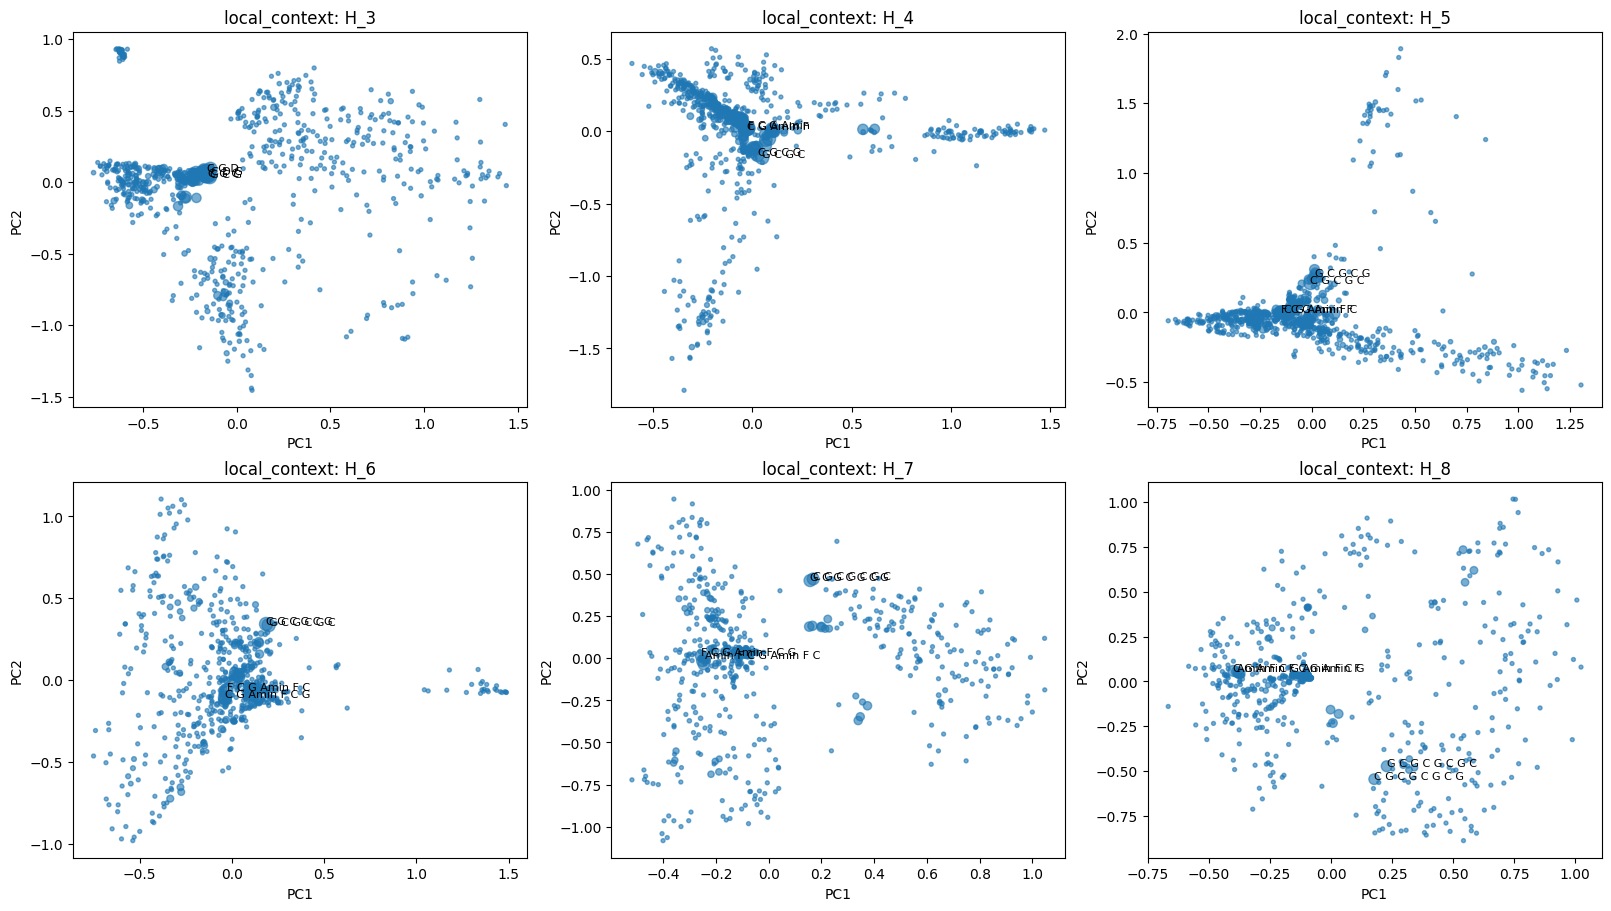

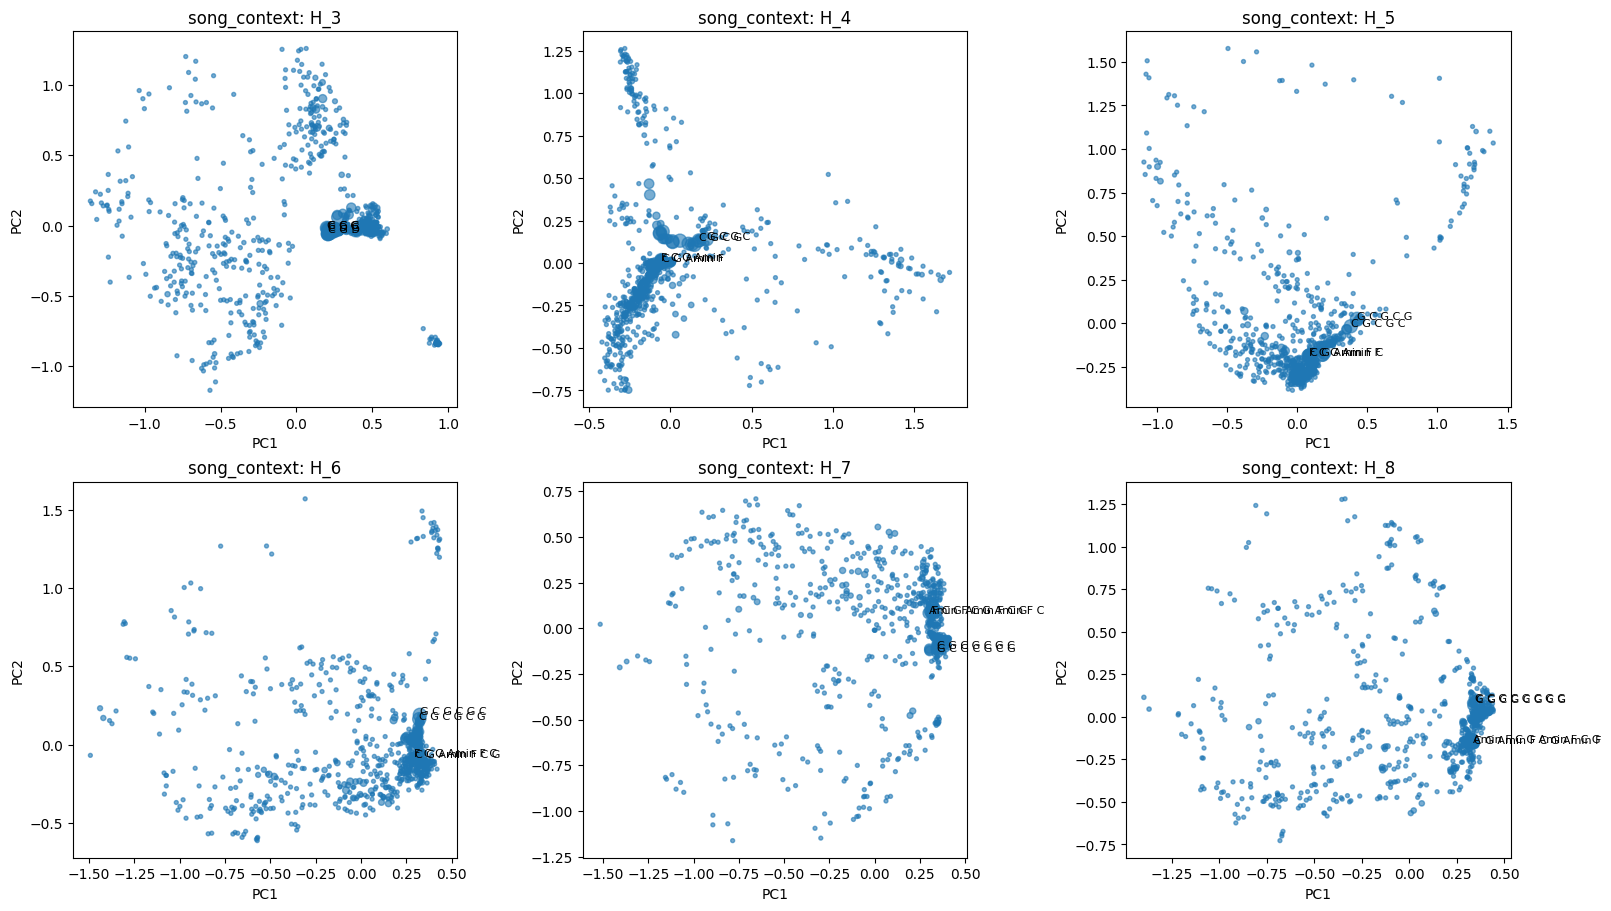

In [11]:
for context_name in sorted(embedding_pca["context"].unique()):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    for ax, n in zip(axes.ravel(), NS):
        sub = embedding_pca[(embedding_pca["context"] == context_name) & (embedding_pca["n"] == n)].copy()
        ax.scatter(sub["PC1"], sub["PC2"], s=np.clip(sub["global_frequency"] * 10000, 8, 90), alpha=0.6)
        ax.set_title(f"{context_name}: H_{n}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        for row in sub.nlargest(4, "global_frequency").itertuples(index=False):
            ax.annotate(row.example_ngram, (row.PC1, row.PC2), fontsize=8)
    plt.show()

## Genre Centroids In Distributional Space

Use the PPMI vectors as a basis, then average them by genre with harmonic document-term frequencies. This produces genre embeddings in the same distributional space.

In [12]:
con = duckdb.connect(str(DB_PATH), read_only=True)
ds.configure_connection(con)
try:
    genre_terms = con.execute(
        """
        SELECT
            document_value AS main_genre,
            n,
            harmonic_id,
            count,
            frequency,
            total_windows,
            song_count
        FROM harmonic_document_terms
        WHERE document_type = 'main_genre'
          AND n BETWEEN 3 AND 8
          AND count >= 100
        """
    ).fetchdf()
finally:
    con.close()

centroid_rows = []
for context_name, by_n in embedding_arrays.items():
    for n, X in by_n.items():
        ids = (song_state if context_name == "song_context" else local_state)[n]["ids"]
        id_to_row = {hid: i for i, hid in enumerate(ids)}
        sub_terms = genre_terms[genre_terms["n"] == n].copy()
        sub_terms = sub_terms[sub_terms["harmonic_id"].isin(id_to_row)]
        for genre, sub in sub_terms.groupby("main_genre"):
            weights = sub["count"].to_numpy(dtype=float)
            weights = weights / weights.sum()
            rows = [id_to_row[hid] for hid in sub["harmonic_id"]]
            centroid = weights @ X[rows]
            centroid_rows.append(
                {
                    "context": context_name,
                    "main_genre": genre,
                    "n": n,
                    "terms": len(sub),
                    "total_count": int(sub["count"].sum()),
                    "song_count": int(sub["song_count"].max()),
                    "centroid_norm": float(np.linalg.norm(centroid)),
                    **{f"z{i + 1}": float(centroid[i]) for i in range(centroid.shape[0])},
                }
            )

genre_distributional_centroids = pd.DataFrame(centroid_rows)
display(genre_distributional_centroids.head())
genre_distributional_centroids.to_csv(OUT_DIR / "genre_distributional_embedding_centroids.csv", index=False)

,context,main_genre,n,terms,total_count,song_count,centroid_norm,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15,z16,z17,z18,z19,z20,z21,z22,z23,z24,z25,z26,z27,z28,z29,z30,z31,z32
0,song_context,alternative,3,749,2989671,47252,0.261861,-0.102684,-0.021901,-0.028002,-0.037975,0.126921,-0.010673,-0.015603,0.003921,0.029775,0.072542,0.065635,0.021735,-0.048238,0.028040,0.011387,0.008796,-0.025981,0.042547,-0.011371,-0.026855,-0.063062,-0.015748,0.035448,-0.015679,-0.022111,-0.046285,-0.029497,-0.058773,-0.027826,-0.078115,-0.038166,-0.015453
1,song_context,country,3,718,3382413,53306,0.248955,-0.131659,-0.059068,-0.010647,-0.095451,0.053576,0.019862,-0.052471,-0.003837,0.012451,0.079482,0.021899,0.024398,-0.028432,0.017215,0.010977,0.000215,-0.040752,0.039528,0.013713,-0.009692,-0.045192,-0.019833,0.032677,-0.015304,-0.000610,-0.043419,-0.007768,-0.054847,-0.014050,-0.060885,-0.032010,-0.000478
2,song_context,electronic,3,176,176337,2814,0.287585,-0.041465,-0.009627,-0.004799,-0.027201,0.093898,-0.004361,0.014541,0.006253,0.050786,0.087757,0.089939,0.036710,-0.071305,0.023287,0.012021,0.005117,-0.033389,0.057770,-0.030207,-0.035476,-0.095344,-0.014575,0.037352,-0.015613,-0.024793,-0.042388,-0.044420,-0.077254,-0.041963,-0.113720,-0.048499,-0.023798
3,song_context,jazz,3,443,343431,7001,0.321708,-0.186369,-0.156383,-0.029063,-0.090575,0.092113,-0.024155,-0.050683,-0.005885,0.021357,0.052661,0.027036,0.040614,-0.050125,0.011486,-0.015510,-0.014086,-0.029640,0.038421,0.016667,-0.005490,-0.056344,-0.018001,0.030221,-0.016191,-0.005645,-0.044980,-0.015300,-0.042665,-0.010297,-0.050262,-0.024564,-0.014543
4,song_context,metal,3,465,855181,11315,0.312795,-0.046646,-0.011523,-0.094195,-0.041289,0.188458,-0.057156,-0.021426,0.003031,0.004631,0.060691,0.068157,0.030954,-0.071677,0.017196,0.016850,-0.004091,-0.041097,0.042534,-0.033038,-0.033766,-0.073709,-0.007821,0.043398,-0.007474,-0.015596,-0.044659,-0.043777,-0.057844,-0.022525,-0.091336,-0.027087,-0.020356


## Export Summary

The most important outputs are:

- `harmonic_ppmi_svd_embeddings.csv`: embedding vectors;
- `harmonic_distributional_neighbors.csv`: nearest neighbors by PPMI/SVD vectors;
- `structural_vs_distributional_neighbor_overlap.csv`: cases where structural and distributional similarity differ;
- `genre_distributional_embedding_centroids.csv`: genre-level harmonic embeddings.

The `.npz` files store dense co-occurrence and PPMI matrices by `n` and context. For a full run, expect this notebook to take materially longer than the earlier summary notebooks because it streams the raw chord corpus and factors dense matrices.

In [13]:
outputs = sorted(p.name for p in OUT_DIR.glob("*"))
outputs

['genre_distributional_embedding_centroids.csv',
 'harmonic_cooccurrence_summary.csv',
 'harmonic_distributional_embedding_pca_scores.csv',
 'harmonic_distributional_embedding_pca_summary.csv',
 'harmonic_distributional_neighbors.csv',
 'harmonic_distributional_vocabulary.csv',
 'harmonic_ppmi_svd_embeddings.csv',
 'harmonic_ppmi_svd_summary.csv',
 'harmonic_structural_baseline_neighbors.csv',
 'local_context_H3_cooccurrence.npz',
 'local_context_H3_ppmi.npz',
 'local_context_H4_cooccurrence.npz',
 'local_context_H4_ppmi.npz',
 'local_context_H5_cooccurrence.npz',
 'local_context_H5_ppmi.npz',
 'local_context_H6_cooccurrence.npz',
 'local_context_H6_ppmi.npz',
 'local_context_H7_cooccurrence.npz',
 'local_context_H7_ppmi.npz',
 'local_context_H8_cooccurrence.npz',
 'local_context_H8_ppmi.npz',
 'song_context_H3_cooccurrence.npz',
 'song_context_H3_ppmi.npz',
 'song_context_H4_cooccurrence.npz',
 'song_context_H4_ppmi.npz',
 'song_context_H5_cooccurrence.npz',
 'song_context_H5_ppmi.npz